In [1]:
import os
import pandas as pd
from matplotlib import pyplot as plt
from utilsforecast.plotting import plot_series
import yfinance as yf
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# amd = yf.Ticker("AMD")
ticker = 'AMD'
num_years = 5
interval_days = 1
download_fresh = True
if not download_fresh and os.path.exists(f'../data/{ticker}_{num_years}y_daily.csv'):
    daily_data = pd.read_csv(f'../data/{ticker}_{num_years}y_daily.csv', index_col=0)
else:
    daily_data = yf.download(tickers=ticker, period=f'{num_years}y', interval=f'{interval_days}d')

[*********************100%***********************]  1 of 1 completed


In [54]:
daily_data.to_csv(f'../data/{ticker}_{num_years}y_daily.csv')

In [3]:
daily_data.columns = daily_data.columns.droplevel(1)
print(daily_data.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [4]:
daily_data[['Close', 'High', 'Low', 'Open', 'Volume']] = daily_data[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)
daily_data.index = pd.to_datetime(daily_data.index)

In [5]:
daily_data[:2]

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-12-07,94.070000,95.000000,92.970001,94.949997,39815700.0
2020-12-08,92.919998,94.739998,91.900002,94.050003,33907500.0


In [6]:
melt_df = daily_data.reset_index().melt(id_vars='Date', var_name='unique_id', value_name='y')
print(melt_df[:2])

        Date unique_id          y
0 2020-12-07     Close  94.070000
1 2020-12-08     Close  92.919998


In [118]:
amd_close = melt_df[melt_df['unique_id'].str.endswith('Close')]
amd_close[:2]

,Date,unique_id,y
0,2020-12-07,Close,94.070000
1,2020-12-08,Close,92.919998


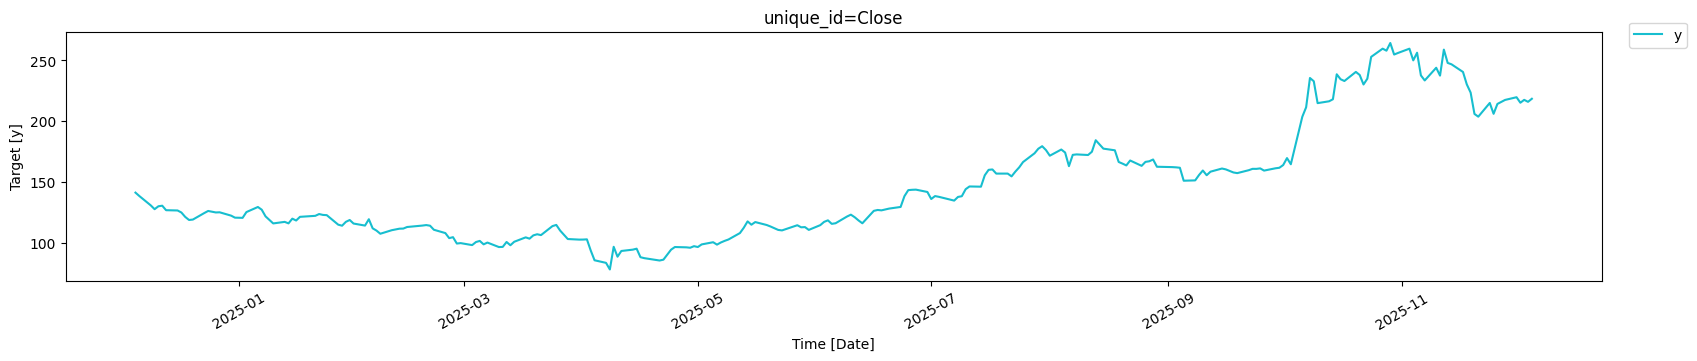

In [31]:
fig = plot_series(df=amd_close, id_col='unique_id', target_col='y', time_col='Date')
fig

In [19]:
amd_close = amd_close.rename(columns={"Date": "ds"})

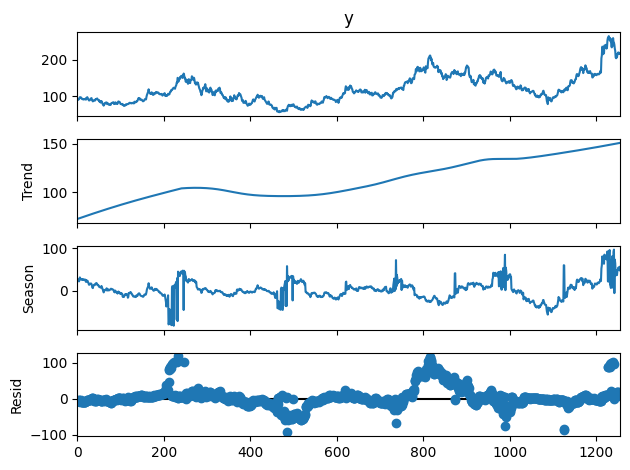

In [73]:
from statsmodels.tsa.seasonal import STL
stl = STL(amd_close['y'], period=252, robust=True)
result = stl.fit()
result.plot()
plt.show()

In [43]:
from statsmodels.tsa.stattools import acf
pearson_autocorr = acf(amd_close['y'], nlags=len(amd_close) - 1)


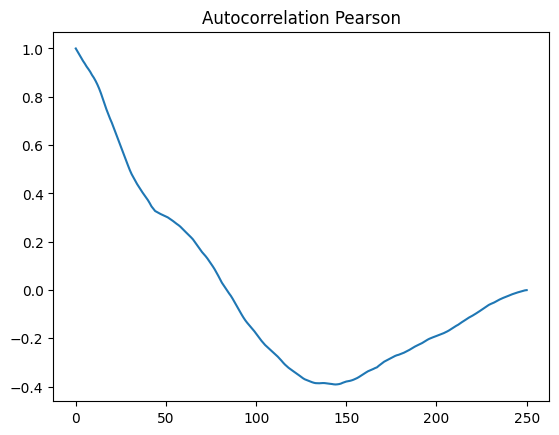

In [44]:
def plot_pearson_autocorrelation(pearson_acf: np.ndarray) -> None:
    lags = np.arange(len(pearson_autocorr))
    plt.plot(lags, pearson_autocorr)
    plt.title('Autocorrelation Pearson')

plot_pearson_autocorrelation(pearson_autocorr)

In [7]:
def split_train_test(df: pd.DataFrame, train_size:float=0.8, train_horizon:float = 1.0) -> tuple[pd.DataFrame, pd.DataFrame]:
    N = len(df)
    train_end = int(N * train_size)
    train_start = train_end - int(train_horizon * train_end)
    train_len = train_end - train_start
    test_len = N - train_len
    df_train = df[train_start:train_end]
    df_test = df[train_end:]
    return df_train, df_test

In [8]:
def multinomial_train_and_predict(df_train: pd.DataFrame, df_test: pd.DataFrame, features:list[str], p:int=12) -> np.ndarray:
    train_len = len(df_train)
    test_len = len(df_test)
    X_train = []
    y_train = []

    for t in range(p, train_len):
        lagged = []
        for lag in range(1, p + 1):
            lagged.extend(df_train.iloc[t - lag][features].values)
        X_train.append(lagged)
        y_train.append(df_train.iloc[t]["y"])

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    coef = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

    X_test = []
    history = pd.concat([df_train.tail(p), df_test], axis=0)
    history = history.reset_index(drop=True)

    for t in range(p, p + test_len):
        lagged = []
        for lag in range(1, p + 1):
            lagged.extend(history.iloc[t - lag][features].values)
        X_test.append(lagged)

    X_test = np.array(X_test)

    y_pred = X_test @ coef
    return y_pred


In [62]:
def train_and_predict(y_train: np.ndarray, y_test: np.ndarray, p:int=12) -> np.ndarray:
    train_len = len(y_train)
    test_len = len(y_test)
    Y_train = np.zeros((train_len - p, p))
    y_target_train = y_train[p:]
    for i in range(train_len - p):
        Y_train[i, :] = y_train[i: i + p][::-1]
    ar_coefficients = np.linalg.lstsq(Y_train, y_target_train)[0]

    Y_test = np.zeros((test_len, p))
    test_history = np.concatenate((y_train[-p:], y_test))
    for i in range(test_len):
        Y_test[i, :] = test_history[i: i + p][::-1]

    y_pred = Y_test @ ar_coefficients
    return y_pred

In [97]:
df_train, df_test = split_train_test(amd_close, train_size=0.8, train_horizon=0.65)
y_pred = train_and_predict(df_train['y'], df_test['y'], p=5)

In [9]:
def calc_loss(y_test: np.ndarray, y_pred:np.ndarray) -> float:
    rmse = np.sqrt(1/len(y_pred)*np.sum((y_test-y_pred)**2))
    return rmse


In [155]:
print('Root Mean squared error: ', calc_loss(df_test['y'], y_pred))

Root Mean squared error:  0.006835836274673


In [10]:
def plot_test_predictions(test_df: pd.DataFrame, y_pred:np.ndarray) -> None:
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 5))
    ax.set_title('True series vs prediction')
    ax.plot(test_df.index, test_df['y'], label='y_test')
    ax.plot(test_df.index, y_pred, label='y_pred')
    ax.legend()
    plt.tight_layout()

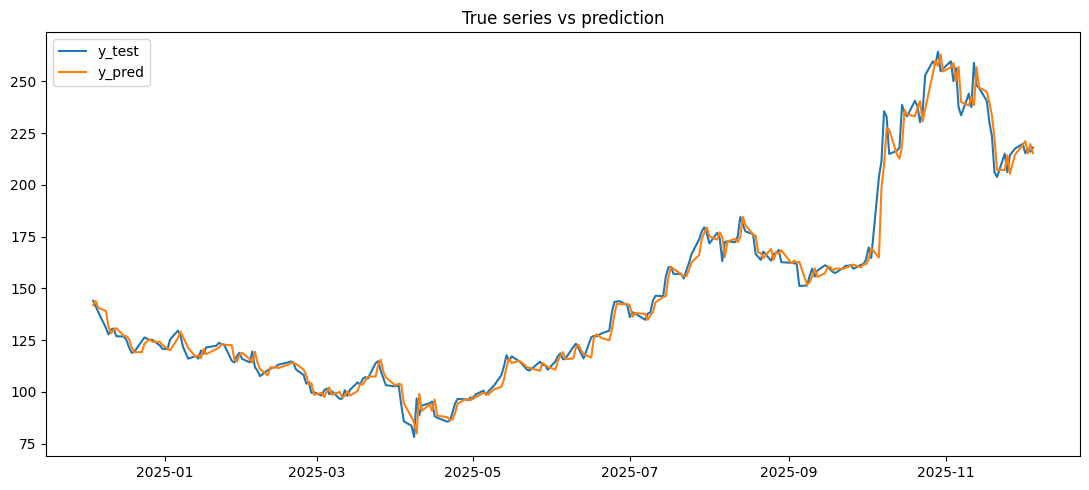

In [146]:
plot_test_predictions(df_test, y_pred)

In [11]:
def plot_test_loss(test_df: pd.DataFrame, y_pred:np.ndarray) -> None:
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 5))
    ax.set_title('Test Loss')
    ax.plot(test_df.index, np.abs(test_df['y']-y_pred), label='test_loss_abs')
    ax.legend()
    plt.tight_layout()

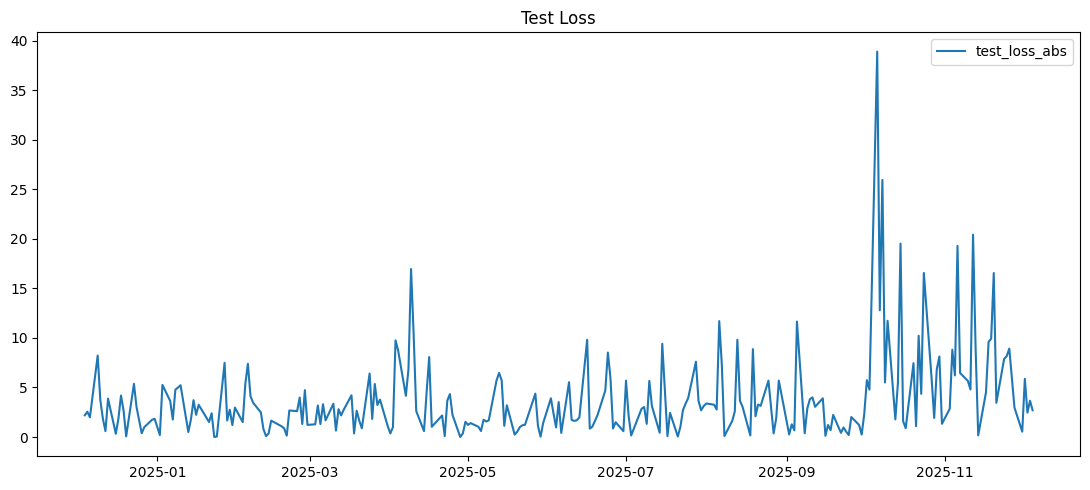

In [148]:
plot_test_loss(df_test, y_pred)

In [80]:
def tune_ar_model(df: pd.DataFrame) -> None:
    n = len(df)
    p_s = np.arange(5, 30, 1)
    train_horizons = np.arange(0.5, 1, 0.05)
    best_params = {
        "p": 6,
        "train_horizon": 0.6,
        "rmse": 20
    }
    for p in p_s:
        for train_horizon in train_horizons:
            df_train, df_test = split_train_test(df, train_size=0.8, train_horizon=train_horizon)
            y_pred = train_and_predict(df_train['y'], df_test['y'], p=p)
            rmse = calc_loss(df_test['y'], y_pred)
            if rmse < best_params["rmse"]:
                best_params["p"] = p
                best_params["train_horizon"] = train_horizon
                best_params["rmse"] = rmse
    print("Best params:", best_params)

In [96]:
tune_ar_model(amd_close)

Best params: {'p': np.int64(5), 'train_horizon': np.float64(0.6500000000000001), 'rmse': np.float64(0.0367752197680697)}


In [92]:
#amd_close['returns'] = amd_close['y'].pct_change()
amd_close['returns'] = amd_close['y'] / amd_close['y'].shift(1)
amd_close['log_returns'] = amd_close['returns'].apply(np.log)
amd_close['close'] = amd_close['y']
amd_close['log_returns'][:5]

0         NaN
1   -0.012300
2   -0.033820
3    0.020167
4   -0.000109
Name: log_returns, dtype: float64

In [95]:
amd_close['y'] = amd_close['log_returns']
amd_close = amd_close.dropna(axis=0)

In [108]:
log_cum_sum = np.cumsum(y_pred, axis=0)
norm_prices = np.exp(log_cum_sum)
initial_price = df_train.iloc[-1]['close']
prices = initial_price * norm_prices
print(prices[:3])

[143.72709773 143.54579942 143.69659651]


In [140]:
daily_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'RSI14', 'pct_change',
       'change_dir', 'smooth_close', 'log_volume', 'y', 'SMA10', 'MACD',
       'MACD_signal', 'MACD_hist', 'target_5day_mean'],
      dtype='object', name='Price')

In [149]:
daily_data["target_5day_mean"] = (
    daily_data["log_return"]
    .shift(-1)     # shift so next-day return is aligned with today
    .rolling(window=5)
    .mean()
)

In [153]:
daily_data["target_5day_mean"].tail(2)

Date
2025-12-01    0.001585
2025-12-02         NaN
Name: target_5day_mean, dtype: float64

In [154]:
features = ['log_return', 'log_volume', 'RSI14', 'MACD_signal', 'y']
daily_data['y'] = daily_data['target_5day_mean']
df_train, df_test = split_train_test(daily_data[:-1], train_size=0.8, train_horizon=0.65)

y_pred = multinomial_train_and_predict(
    df_train=df_train,
    df_test=df_test,
    features=features,
    p=5
)

In [135]:
from sklearn.metrics import accuracy_score
y_pred_target = (y_pred > 0.5).astype(int)
#y_pred_target = df_test['y'].shift(1)
#y_pred_target[0] = 0
acc_score = accuracy_score(df_test['y'], y_pred_target)
print(acc_score)
print(np.unique(y_pred_target, return_counts=True))
print(np.unique(df_test['y'], return_counts=True))

0.4860557768924303
(array([0, 1]), array([148, 103]))
(array([0, 1]), array([123, 128]))


In [57]:
def tune_multinomial_ar_model(df: pd.DataFrame, features: list[str]) -> None:
    p_s = np.arange(5, 10, 1)
    train_horizons = np.arange(0.55, 0.75, 0.05)
    best_params = {
        "p": 5,
        "train_horizon": 0.6,
        "rmse": 20,
        "acc_score": 0.5
    }
    for p in p_s:
        for train_horizon in train_horizons:
            df_train, df_test = split_train_test(df, train_size=0.8, train_horizon=train_horizon)
            y_pred = multinomial_train_and_predict(df_train, df_test, features=features, p=p)
            rmse = calc_loss(df_test['y'], y_pred)
            y_pred_target = (y_pred > 0.5).astype(int)
            acc_score = accuracy_score(df_test['y'], y_pred_target)
            if acc_score > best_params["acc_score"]:
                best_params["p"] = p
                best_params["train_horizon"] = train_horizon
                best_params["rmse"] = rmse
                best_params["acc_score"] = acc_score
    print("Best params:", best_params)

In [50]:
tune_multinomial_ar_model(daily_data, features)

Best params: {'p': np.int64(5), 'train_horizon': np.float64(0.6000000000000001), 'rmse': np.float64(0.5003981375477301), 'acc_score': 0.5714285714285714}


In [151]:
print(calc_loss(df_test['y'], y_pred))

5.886513331908227


In [150]:
y_pred = df_test['y'].shift(1).values
y_pred[0] = y_pred[1]
print(y_pred[:4])

[143.99000549 143.99000549 141.36000061 138.58999634]


In [13]:
def compute_RSI(df, column="Close", window=14):
    # Price changes
    delta = df[column].diff()

    # Separate gains and losses
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)

    # Wilder's exponential moving average
    gain_ema = gain.ewm(alpha=1/window, adjust=False).mean()
    loss_ema = loss.ewm(alpha=1/window, adjust=False).mean()

    # Relative Strength
    rs = gain_ema / loss_ema

    # RSI
    rsi = 100 - (100 / (1 + rs))

    return rsi


In [54]:
def add_SMA_MACD(df, price_col="smooth_close"):
    # SMA 10
    df["SMA10"] = df[price_col].rolling(window=10).mean()

    # MACD
    ema12 = df[price_col].ewm(span=12, adjust=False).mean()
    ema26 = df[price_col].ewm(span=26, adjust=False).mean()

    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_hist"] = df["MACD"] - df["MACD_signal"]


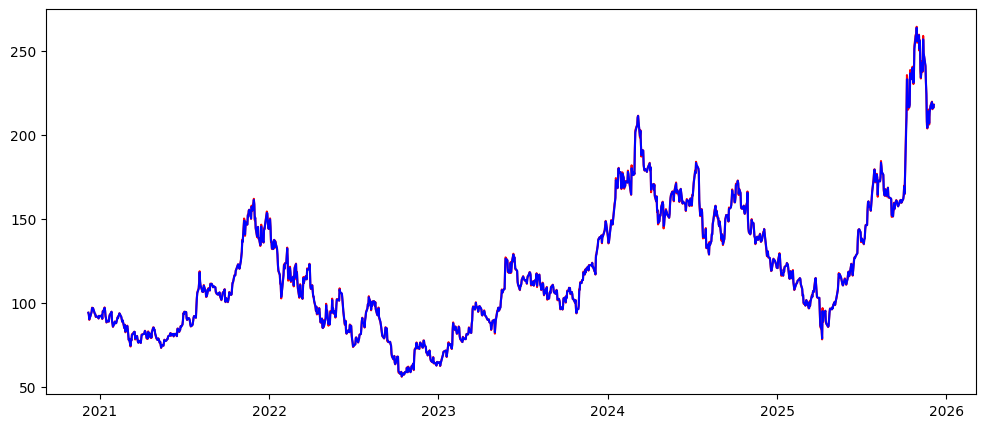

In [26]:
alpha = 0.7
daily_data['smooth_close'] = daily_data['Close'].ewm(alpha=0.9, adjust=False).mean()
plt.figure(figsize=(12, 5))
plt.plot(daily_data.index, daily_data['Close'], label='close', color='red')
plt.plot(daily_data.index, daily_data['smooth_close'], label='smooth_close', color='blue')

In [27]:
daily_data["RSI14"] = compute_RSI(daily_data, column="smooth_close", window=14)

In [28]:
daily_data['pct_change'] = daily_data['smooth_close'].pct_change()
daily_data['change_dir'] = (daily_data['pct_change'] > 0).astype(int)

In [32]:
daily_data['log_volume'] = daily_data['Volume'].apply(np.log)

In [148]:
daily_data['log_return'] = np.log1p(daily_data["pct_change"])

In [55]:
add_SMA_MACD(daily_data)

In [98]:
features = ['pct_change', 'log_volume', 'RSI14', 'MACD_signal', 'y']
daily_data['y'] = daily_data['change_dir'].shift(-1)
daily_data = daily_data[:-1]
daily_data['y'] = daily_data['y'].astype(int)
df_train, df_test = split_train_test(daily_data[features], train_size=0.8, train_horizon=0.65)
print(df_train[:6])

Price       pct_change  log_volume      RSI14  MACD_signal  y
Date                                                         
2022-04-29   -0.036886   18.230098  33.691591    -5.947376  1
2022-05-02    0.041440   18.403576  39.437791    -5.994529  1
2022-05-03    0.016959   18.654818  41.754554    -5.940413  1
2022-05-04    0.083691   19.233361  51.733593    -5.690663  0
2022-05-05   -0.042950   18.846796  46.919149    -5.385964  1
2022-05-06    0.009536   18.787312  48.025981    -5.036167  0


In [99]:
X_train = df_train.drop(columns=['y'], axis=1)
y_train = df_train['y']
X_test = df_test.dropna(axis=0).drop(columns=['y'], axis=1)
y_test = df_test.dropna(axis=0)['y']

In [132]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)
rf = RandomForestClassifier(n_estimators=130, max_depth=5, max_leaf_nodes=6, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,130
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,6
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [133]:
y_pred = rf.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)
print(acc_score)

0.549800796812749


In [158]:
pred_prices = df_test["smooth_close"] * np.exp(y_pred*5)
def plot_test_predictions_from_pct_change(test_df: pd.DataFrame, y_pred:np.ndarray) -> None:
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 5))
    ax.set_title('True series vs prediction')
    ax.plot(test_df.index, test_df['smooth_close'], label='y_test')
    ax.plot(test_df.index, pred_prices, label='y_pred')
    ax.legend()
    plt.tight_layout()

In [162]:
print(y_pred[:4])
print(df_test[:4]['log_return'])
print(y_pred.shape)
print(df_test.shape)

[-0.00091572  0.00199627  0.00781165  0.00964749]
Date
2024-11-29    0.005006
2024-12-02    0.032016
2024-12-03    0.002639
2024-12-04    0.012925
Name: log_return, dtype: float64
(251,)
(251, 17)


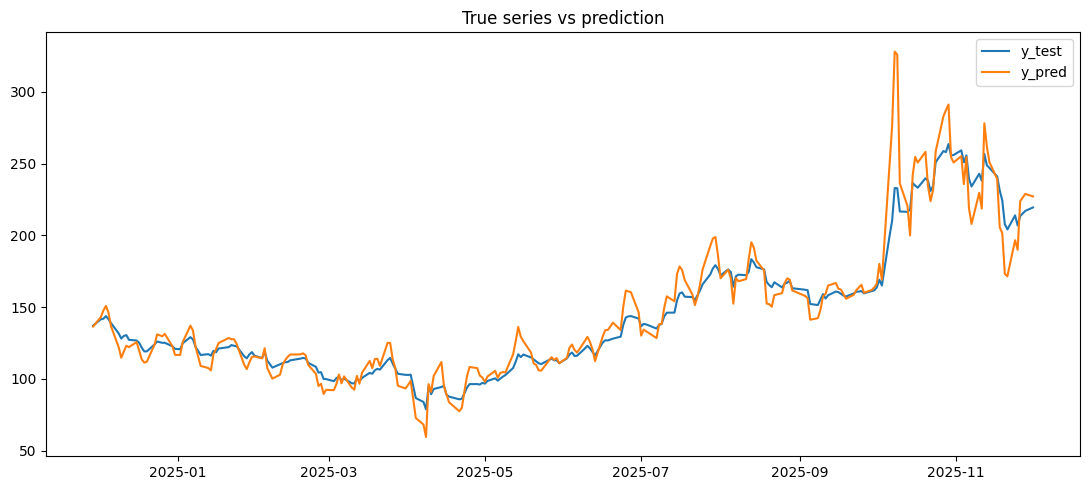

In [159]:
plot_test_predictions_from_pct_change(df_test, y_pred)